In [4]:
import cv2
import matplotlib.pyplot as plt

In [5]:
image_path = "../dataset/processed/glioma/1.png"

image = cv2.imread(image_path)

In [6]:
image = cv2.imread(image_path)

In [7]:
print(image.shape)

(512, 512, 3)


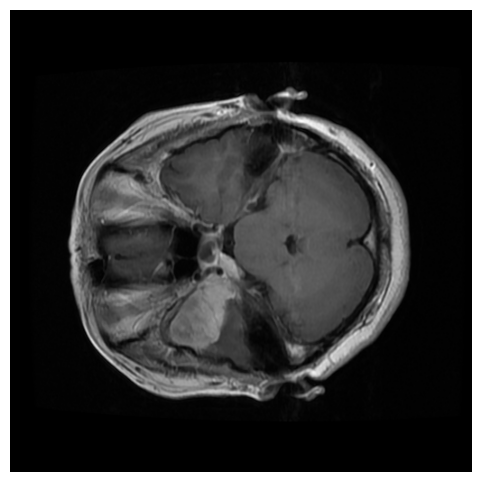

In [8]:
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [9]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print(gray.shape)

(512, 512)


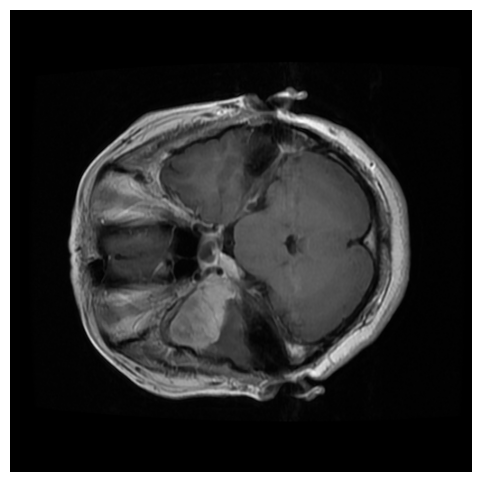

In [10]:
plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

In [12]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

print(blurred.shape)

(512, 512)


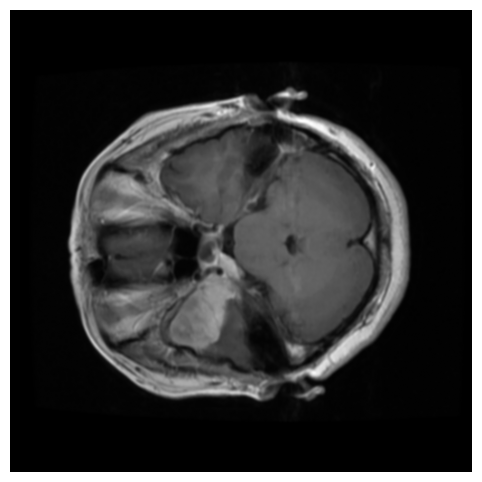

In [14]:
plt.figure(figsize=(6, 6))
plt.imshow(blurred, cmap="gray")
plt.axis("off")
plt.show()

In [21]:
# Step 4: Thresholding

thresh = cv2.threshold(
    blurred,
    45,
    255,
    cv2.THRESH_BINARY
)[1]

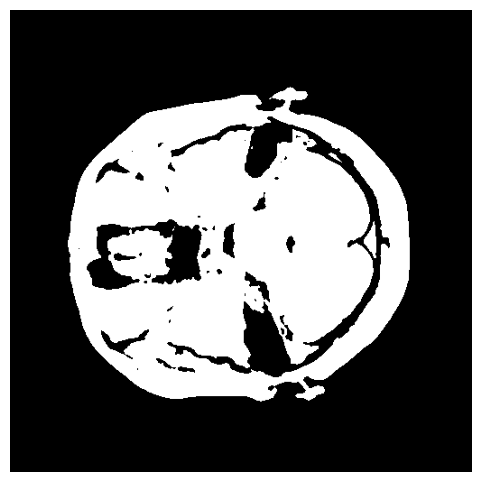

In [22]:
plt.figure(figsize=(6, 6))
plt.imshow(thresh, cmap="gray")
plt.axis("off")
plt.show()

In [23]:
thresh = cv2.erode(
    thresh,
    None,
    iterations=2
)

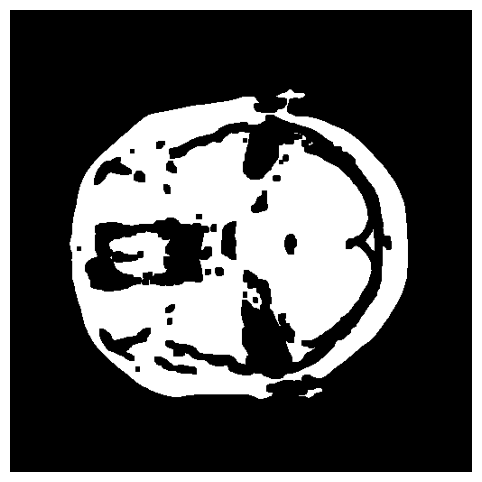

In [24]:
plt.figure(figsize=(6, 6))
plt.imshow(thresh, cmap="gray")
plt.axis("off")
plt.show()

In [25]:
thresh = cv2.dilate(
    thresh,
    None,
    iterations=2
)

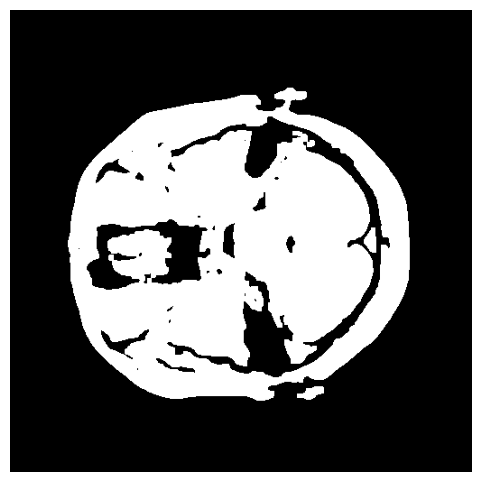

In [26]:
plt.figure(figsize=(6, 6))
plt.imshow(thresh, cmap="gray")
plt.axis("off")
plt.show()

In [28]:
%pip install imutils

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25890 sha256=83ff4cca855fcdf102e4df4b33e2864e9c67f10038d1e5e2d4840e673dbc1126
  Stored in directory: c:\users\lenovo\appdata\local\pip\cache\wheels\31\d0\2c\87ce38f6052879e5b7b18f0f8b4a10ad2a9d210e908d449f16
Successfully built imutils
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import imutils

In [34]:
cnts = cv2.findContours(
    thresh.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

cnts = imutils.grab_contours(cnts)

print("Number of contours:", len(cnts))

Number of contours: 2


In [35]:
# Step 8: Select the largest contour

c = max(cnts, key=cv2.contourArea)

print("Largest contour area:", cv2.contourArea(c))

Largest contour area: 101641.0


In [36]:
# Step 9: Find extreme points

extLeft = tuple(c[c[:, :, 0].argmin()][0])
extRight = tuple(c[c[:, :, 0].argmax()][0])
extTop = tuple(c[c[:, :, 1].argmin()][0])
extBot = tuple(c[c[:, :, 1].argmax()][0])

print("Left:", extLeft)
print("Right:", extRight)
print("Top:", extTop)
print("Bottom:", extBot)

Left: (np.int32(64), np.int32(255))
Right: (np.int32(442), np.int32(287))
Top: (np.int32(307), np.int32(86))
Bottom: (np.int32(273), np.int32(432))


In [37]:
# Step 10: Crop the brain region

new_image = image[
    extTop[1]:extBot[1],
    extLeft[0]:extRight[0]
]

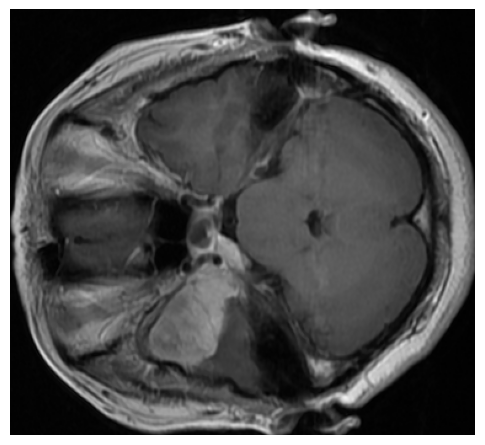

In [38]:
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [39]:
print("Original:", image.shape)
print("Cropped:", new_image.shape)

Original: (512, 512, 3)
Cropped: (346, 378, 3)
